# Production Company Analysis
The objective of this notebook is to analyse the commercial performance of movie production companies. By examining total box office revenue and the number of movies produced by each company, this analysis identifies the production companies that have contributed most significantly to the movie industry.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.ticker import FuncFormatter

In [7]:
clean = r"C:\Users\bongo\OneDrive\Desktop\GitHub\Movie Analysis\Data\Clean\cleaned_movies.csv"

movies = pd.read_csv(clean)

print("Dataset loaded successfully.")

movies.head()

Dataset loaded successfully.


,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,Profit,ROI,released_month,release_quarter,decade
0,The Shining,R,Drama,1980,1980-06-13,8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0,27998772.0,1.473620,1980-06-13,2.0,1980
1,The Blue Lagoon,R,Adventure,1980,1980-07-02,5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0,54353106.0,12.078468,1980-07-02,3.0,1980
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,1980-06-20,8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0,520375067.0,28.909726,1980-06-20,2.0,1980
3,Airplane!,PG,Comedy,1980,1980-07-02,7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0,79953539.0,22.843868,1980-07-02,3.0,1980
4,Caddyshack,R,Comedy,1980,1980-07-25,7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0,33846344.0,5.641057,1980-07-25,3.0,1980


In [8]:
def currency_formatter(x, pos):

    if x >= 1_000_000_000:
        return f"${x/1_000_000_000:.0f}B"

    elif x >= 1_000_000:
        return f"${x/1_000_000:.0f}M"

    else:
        return f"${x:,.0f}"

# Highest Revenue Production Companies

This visualisation compares the total box office revenue generated by the leading production companies in the dataset.

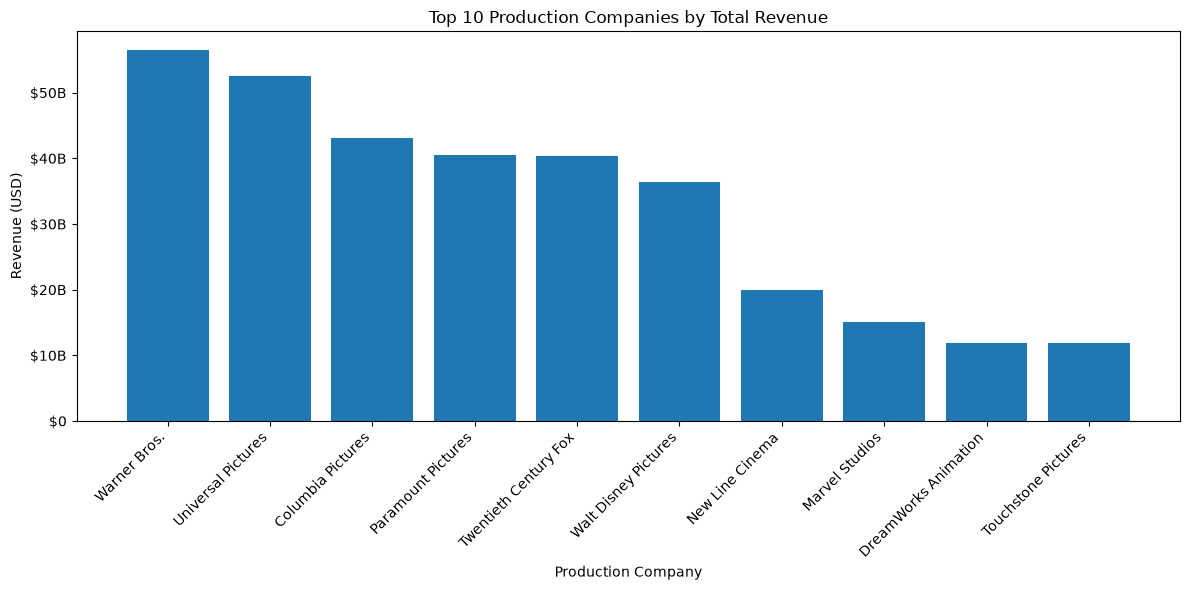

In [9]:
company_revenue = (
    movies
    .groupby("company")["gross"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.bar(
    company_revenue.index,
    company_revenue.values
)

plt.title("Top 10 Production Companies by Total Revenue")

plt.xlabel("Production Company")
plt.ylabel("Revenue (USD)")

plt.xticks(rotation=45, ha="right")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(currency_formatter)
)

plt.tight_layout()

plt.show()

### Findings

This chart highlights the production companies that generated the greatest cumulative box office revenue. Companies appearing near the top have consistently produced commercially successful movies throughout the period covered by the dataset.

# Movie Count by Production Company

This visualisation shows the production companies that released the largest number of movies within the dataset.

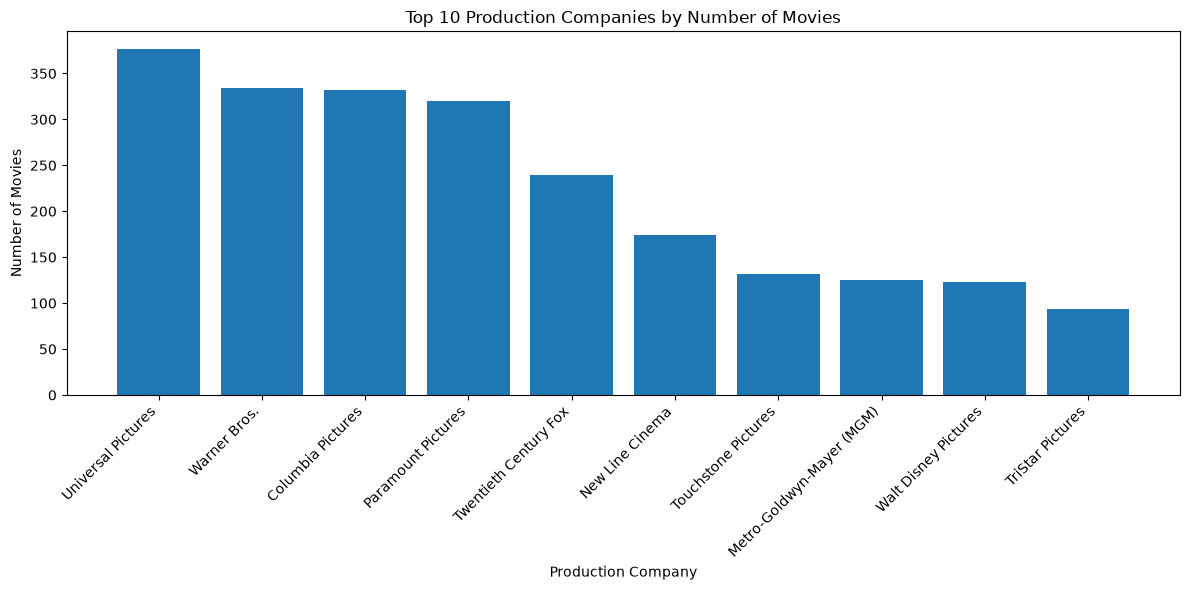

In [10]:
company_count = (
    movies["company"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

plt.bar(
    company_count.index,
    company_count.values
)

plt.title("Top 10 Production Companies by Number of Movies")

plt.xlabel("Production Company")
plt.ylabel("Number of Movies")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

### Findings

The movie count chart identifies the production companies with the highest output. Comparing this visualisation with total revenue helps distinguish companies that produce many movies from those that generate exceptional financial performance.

# Summary

The production company analysis demonstrates that commercial success varies considerably across production companies. While some companies dominate the industry through consistently high box office revenue, others achieve prominence by producing a larger volume of movies. Together, these visualisations provide insight into the influence of production companies on overall movie industry performance.